In [ ]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

# Then extract the files
!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz


--2025-05-18 01:39:08--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2025-05-18 01:39:08--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M   150MB/s    in 8.6s    

2025-05-18 01:39:17 (87.3 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2025-05-18 01:39:18--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.r

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
from glob import glob
from PIL import Image
import random

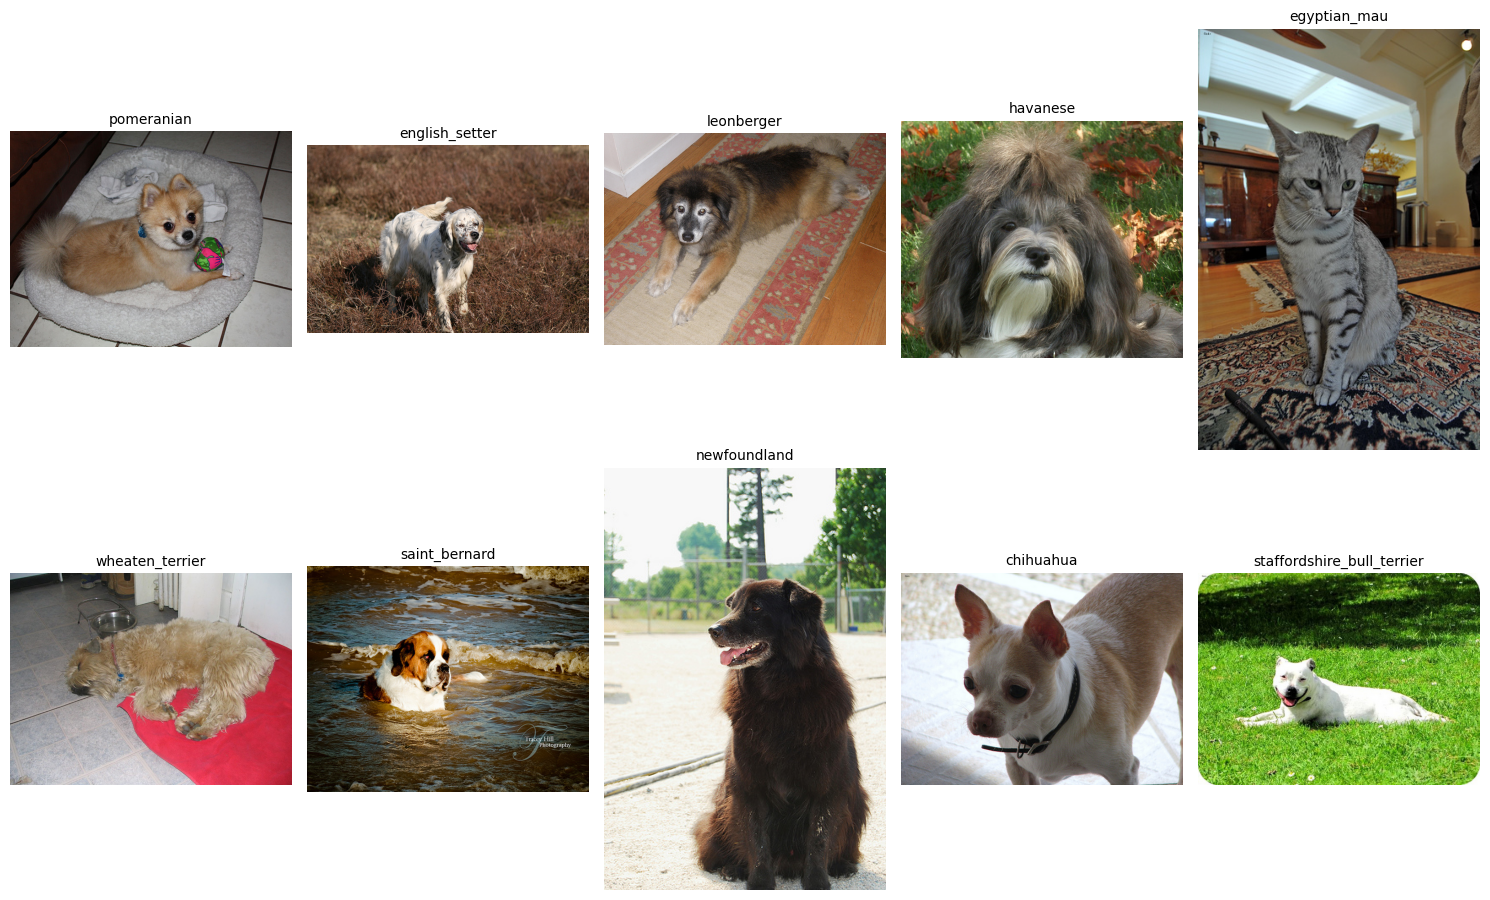

In [ ]:
image_paths = sorted(glob('images/*.jpg'))
classes = sorted(set([os.path.basename(path).rsplit('_', 1)[0].lower() for path in image_paths]))
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

sample_classes = random.sample(classes, 10)

plt.figure(figsize=(15, 10))

for i, cls in enumerate(sample_classes):
    cls_images = [p for p in image_paths if os.path.basename(p).lower().startswith(cls)]
    sample_img_path = random.choice(cls_images)

    img = Image.open(sample_img_path)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(cls, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
print(f"Total classes: {len(classes)}")
print("First 10 class names:")
print(classes[:10])


Total classes: 37
First 10 class names:
['abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'bengal', 'birman', 'bombay', 'boxer', 'british_shorthair']


In [ ]:
from collections import defaultdict

# Count images per class
image_counts = defaultdict(int)

for path in image_paths:
    class_name = os.path.basename(path).rsplit('_', 1)[0].lower()
    image_counts[class_name] += 1

# Convert to sorted list of tuples
sorted_counts = sorted(image_counts.items(), key=lambda x: x[0])

# Display
for cls, count in sorted_counts:
    print(f"{cls}: {count} images")

abyssinian: 200 images
american_bulldog: 200 images
american_pit_bull_terrier: 200 images
basset_hound: 200 images
beagle: 200 images
bengal: 200 images
birman: 200 images
bombay: 200 images
boxer: 200 images
british_shorthair: 200 images
chihuahua: 200 images
egyptian_mau: 200 images
english_cocker_spaniel: 200 images
english_setter: 200 images
german_shorthaired: 200 images
great_pyrenees: 200 images
havanese: 200 images
japanese_chin: 200 images
keeshond: 200 images
leonberger: 200 images
maine_coon: 200 images
miniature_pinscher: 200 images
newfoundland: 200 images
persian: 200 images
pomeranian: 200 images
pug: 200 images
ragdoll: 200 images
russian_blue: 200 images
saint_bernard: 200 images
samoyed: 200 images
scottish_terrier: 199 images
shiba_inu: 200 images
siamese: 200 images
sphynx: 200 images
staffordshire_bull_terrier: 191 images
wheaten_terrier: 200 images
yorkshire_terrier: 200 images


In [ ]:
import shutil
from glob import glob
from tqdm import tqdm

# Start clean
output_dir = "pet_images_by_class"
os.makedirs(output_dir, exist_ok=True)

for filepath in tqdm(glob("images/*.jpg")):
    filename = os.path.basename(filepath)
    class_name = filename.rsplit("_", 1)[0].lower()
    class_path = os.path.join(output_dir, class_name)
    os.makedirs(class_path, exist_ok=True)
    shutil.copy(filepath, class_path)


100%|██████████| 7390/7390 [00:12<00:00, 602.70it/s]


In [ ]:
IMG_SIZE = (128,128)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    "pet_images_by_class",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "pet_images_by_class",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)


Found 7390 files belonging to 37 classes.
Using 5912 files for training.
Found 7390 files belonging to 37 classes.
Using 1478 files for validation.
Classes: ['abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'bengal', 'birman', 'bombay', 'boxer', 'british_shorthair', 'chihuahua', 'egyptian_mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'maine_coon', 'miniature_pinscher', 'newfoundland', 'persian', 'pomeranian', 'pug', 'ragdoll', 'russian_blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'siamese', 'sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']
